# Affinity Classification Diagnostics

This notebook computes a compact set of diagnostic metrics for ordinal affinity labels on `(abstract, question)` pairs.

Metrics included:
1. Confusion matrix against expert labels
2. Per-class recall
3. Quadratic Weighted Kappa
4. Mean signed error
5. Reliability curve

Optional: cluster bootstrap confidence intervals (disabled by default).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, cohen_kappa_score

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 120

In [2]:
# Label definitions (edit only if your taxonomy changes).
LABEL_ORDER = ["Low", "Moderate", "High"]
LABEL_TO_NUM = {"Low": 0, "Moderate": 1, "High": 2}
NUM_TO_LABEL = {0: "Low", 1: "Moderate", 2: "High"}

# Editable column names.
expert_col = "expert_label"
prediction_col = "final_label"
abstract_id_col = "abstract_id"

agreement_strength_col = None
panel_vote_cols = []

# Optional: per-model signed-bias diagnostics.
model_prediction_cols = []

# Optional cluster bootstrap (disabled by default).
RUN_BOOTSTRAP = False
N_BOOT = 500
BOOTSTRAP_SEED = 42

## Load Data

The loader tries likely project files first (including benchmark and calibration outputs), then you can override `input_path` manually if needed.

In [40]:
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
bench_root = repo_root / "data" / "results" / "affinity_benchmark"
calib_root = repo_root / "data" / "results" / "affinity_calibration"

benchmark_run_dir_names = ["20260422_212121_1", "20260422_212121_2", "20260422_212121_3"]
calibration_run_dir_names = ["20260601_dummy_100_abstracts_v3"]

benchmark_input_filename = "adjudicated_ra_model_rows.csv"
calibration_input_filename = "calibration_dummy_abstract_question_affinities.csv"

def load_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file extension for {path}")

def collect_frames(root: Path, run_dir_names, input_filename: str, source_name: str):
    if isinstance(run_dir_names, (str, Path)):
        run_dir_names = [run_dir_names]

    run_dirs = sorted([p for p in root.iterdir() if p.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f"No run directories found under {root}")

    selected_run_dirs = [p for p in run_dirs if p.name in {str(x) for x in run_dir_names}]
    if not selected_run_dirs:
        raise FileNotFoundError(f"No matching run directories found for: {run_dir_names}")

    frames = []
    for run_dir in selected_run_dirs:
        input_path = run_dir / input_filename
        if not input_path.exists():
            raise FileNotFoundError(f"Missing file: {input_path}")

        run_df = load_table(input_path)
        run_df["Run_ID"] = run_dir.name
        run_df["Source_Type"] = source_name
        frames.append(run_df)

    return frames, selected_run_dirs

benchmark_frames, selected_benchmark_dirs = collect_frames(
    bench_root, benchmark_run_dir_names, benchmark_input_filename, "benchmark"
 )
calibration_frames, selected_calibration_dirs = collect_frames(
    calib_root, calibration_run_dir_names, calibration_input_filename, "calibration"
 )

df_raw = pd.concat(benchmark_frames + calibration_frames)


bench_df = pd.concat(benchmark_frames, ignore_index=True)
calib_df = pd.concat(calibration_frames, ignore_index=True)
df_raw = pd.merge(bench_df, calib_df, on=['Abstract_Index', 'RA2025_ID'], how='inner', suffixes=('_bench', '_calib'))

print("Benchmark run directories:", [p.name for p in selected_benchmark_dirs])
print("Calibration run directories:", [p.name for p in selected_calibration_dirs])
print("Calibration abstracts:", calib_df['Abstract_Index'].nunique())
print("Benchmark abstracts:", bench_df['Abstract_Index'].nunique())
print("Rows loaded:", len(df_raw))
print(f"Columns ({len(df_raw.columns)}): {list(df_raw.columns)}")
display(df_raw.head(10))

Benchmark run directories: ['20260422_212121_1', '20260422_212121_2', '20260422_212121_3']
Calibration run directories: ['20260601_dummy_100_abstracts_v3']
Calibration abstracts: 100
Benchmark abstracts: 300
Rows loaded: 2148
Columns (23): ['Abstract_Index', 'Document Title_bench', 'RA2025_ID', 'RA_Question_bench', 'Cosine_x100', 'LLM_Affinity', 'LLM_Affinity_Reason', 'Model_Slug', 'Run_ID_bench', 'Abstract_Index_Norm', 'Affinity_Level', 'Final_Affinity', 'Final_Method', 'Final_Reason', 'Source_Type_bench', 'Document Title_calib', 'RA_Question_calib', 'Evaluator_Affinity', 'Evaluator_Affinity_Level', 'Evaluator_Affinity_Reason', 'Source_Evaluator', 'Run_ID_calib', 'Source_Type_calib']


,Abstract_Index,Document Title_bench,RA2025_ID,RA_Question_bench,Cosine_x100,LLM_Affinity,LLM_Affinity_Reason,Model_Slug,Run_ID_bench,Abstract_Index_Norm,...,Final_Reason,Source_Type_bench,Document Title_calib,RA_Question_calib,Evaluator_Affinity,Evaluator_Affinity_Level,Evaluator_Affinity_Reason,Source_Evaluator,Run_ID_calib,Source_Type_calib
0,2,Domain of Stability Characterization for Power...,11,in what form and fidelity should the original ...,39.9416,40,Focuses on mathematical modeling of nonlinear ...,gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,in what form and fidelity should the original ...,38.5,Low,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
1,2,Domain of Stability Characterization for Power...,20,how can grid topology be flexibly adapted to b...,30.6336,30,"The method is for stability analysis, not spec...",gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,how can grid topology be flexibly adapted to b...,46.8,Moderate,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
2,2,Domain of Stability Characterization for Power...,21,what applications are required to assess adequ...,29.8855,30,Focuses on stability analysis rather than asse...,gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,what applications are required to assess adequ...,68.0,Moderate,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
3,2,Domain of Stability Characterization for Power...,35,"what models and methods, including testing, ar...",25.0685,40,"Provides a method to quantify stability, which...",gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,"what models and methods, including testing, ar...",59.6,Moderate,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
4,2,Domain of Stability Characterization for Power...,16,what is the communication capability needed to...,9.3757,20,No relation to communication requirements.,gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,what is the communication capability needed to...,16.0,Low,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
5,2,Domain of Stability Characterization for Power...,28,what system services are needed across differe...,5.6323,20,No relation to service design across timescales.,gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,what system services are needed across differe...,15.3,Low,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
6,2,Domain of Stability Characterization for Power...,31,"for each service, how feasible is it to provid...",1.0724,30,Stability analysis is relevant to service prov...,gemini-3.1-flash-lite,20260422_212121_1,2,...,"Most models rated this low (0-30), with one mo...",benchmark,Domain of Stability Characterization for Power...,"for each service, how feasible is it to provid...",59.6,Moderate,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
7,3,Stochastic Transmission Planning: Latent Facto...,12,what mechanisms and appropriate aggregate der ...,44.7799,0,No relevance to DER representation or data in ...,gemini-3.1-flash-lite,20260422_212121_1,3,...,NaN,benchmark,Stochastic Transmission Planning: Latent Facto...,what mechanisms and appropriate aggregate der ...,70.3,High,Synthet

In [41]:
df_raw

,Abstract_Index,Document Title_bench,RA2025_ID,RA_Question_bench,Cosine_x100,LLM_Affinity,LLM_Affinity_Reason,Model_Slug,Run_ID_bench,Abstract_Index_Norm,...,Final_Reason,Source_Type_bench,Document Title_calib,RA_Question_calib,Evaluator_Affinity,Evaluator_Affinity_Level,Evaluator_Affinity_Reason,Source_Evaluator,Run_ID_calib,Source_Type_calib
0,2,Domain of Stability Characterization for Power...,11,in what form and fidelity should the original ...,39.9416,40,Focuses on mathematical modeling of nonlinear ...,gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,in what form and fidelity should the original ...,38.5,Low,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
1,2,Domain of Stability Characterization for Power...,20,how can grid topology be flexibly adapted to b...,30.6336,30,"The method is for stability analysis, not spec...",gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,how can grid topology be flexibly adapted to b...,46.8,Moderate,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
2,2,Domain of Stability Characterization for Power...,21,what applications are required to assess adequ...,29.8855,30,Focuses on stability analysis rather than asse...,gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,what applications are required to assess adequ...,68.0,Moderate,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
3,2,Domain of Stability Characterization for Power...,35,"what models and methods, including testing, ar...",25.0685,40,"Provides a method to quantify stability, which...",gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,"what models and methods, including testing, ar...",59.6,Moderate,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
4,2,Domain of Stability Characterization for Power...,16,what is the communication capability needed to...,9.3757,20,No relation to communication requirements.,gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,what is the communication capability needed to...,16.0,Low,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2143,298,Optimized Unsymmetrical Per-Phase Droop for So...,5,what recommendations for standard ibr frequenc...,11.0326,30,Proposes droop control but does not address st...,mistral-large-3-675b-cloud,20260422_212121_3,298,...,NaN,benchmark,Optimized Unsymmetrical Per-Phase Droop for So...,what recommendations for standard ibr frequenc...,57.6,Moderate,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
2144,298,Optimized Unsymmetrical Per-Phase Droop for So...,17,what is a scalable data architecture for der m...,10.9921,10,No discussion on scalable data architecture fo...,mistral-large-3-675b-cloud,20260422_212121_3,298,...,NaN,benchmark,Optimized Unsymmetrical Per-Phase Droop for So...,what is a scalable data architecture for der m...,45.5,Moderate,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
2145,298,Optimized Unsymmetrical Per-Phase Droop for So...,28,what system services are needed across differe...,6.7445,20,No discussion on system services across timesc...,mistral-large-3-675b-cloud,20260422_212121_3,298,...,NaN,benchmark,Optimized Unsymmetrical Per-Phase Droo

In [47]:
def infer_column(columns, preferred, fallback):
    if preferred in columns:
        return preferred
    lower_map = {str(c).strip().lower(): c for c in columns}
    for name in fallback:
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    return None

expert_col_inferred = infer_column(
    df_raw.columns,
    expert_col,
    [
        'expert_label', 'benchmark_label', 
        'expert_affinity', 'gold_label', 'gold_affinity', 'Evaluator_Affinity_Level'
    ],
)
prediction_col_inferred = infer_column(
    df_raw.columns,
    prediction_col,
    [
        'Affinity_Level'
    ],
)
abstract_id_col_inferred = infer_column(
    df_raw.columns,
    abstract_id_col,
    ['abstract_id', 'Abstract_Index', 'abstract_index', 'Source_Index'],
)

print('Column mapping in use:')
print(f'  expert_col      -> {expert_col_inferred}')
print(f'  prediction_col  -> {prediction_col_inferred}')
print(f'  abstract_id_col -> {abstract_id_col_inferred}')

if expert_col_inferred is None or prediction_col_inferred is None:
    raise ValueError(
        'Could not find expert/prediction label columns automatically. '
        'Please edit expert_col and prediction_col near the top of this notebook.'
    )

Column mapping in use:
  expert_col      -> Evaluator_Affinity_Level
  prediction_col  -> Affinity_Level
  abstract_id_col -> Abstract_Index


In [48]:
df_raw

,Abstract_Index,Document Title_bench,RA2025_ID,RA_Question_bench,Cosine_x100,LLM_Affinity,LLM_Affinity_Reason,Model_Slug,Run_ID_bench,Abstract_Index_Norm,...,Final_Reason,Source_Type_bench,Document Title_calib,RA_Question_calib,Evaluator_Affinity,Evaluator_Affinity_Level,Evaluator_Affinity_Reason,Source_Evaluator,Run_ID_calib,Source_Type_calib
0,2,Domain of Stability Characterization for Power...,11,in what form and fidelity should the original ...,39.9416,40,Focuses on mathematical modeling of nonlinear ...,gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,in what form and fidelity should the original ...,38.5,Low,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
1,2,Domain of Stability Characterization for Power...,20,how can grid topology be flexibly adapted to b...,30.6336,30,"The method is for stability analysis, not spec...",gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,how can grid topology be flexibly adapted to b...,46.8,Moderate,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
2,2,Domain of Stability Characterization for Power...,21,what applications are required to assess adequ...,29.8855,30,Focuses on stability analysis rather than asse...,gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,what applications are required to assess adequ...,68.0,Moderate,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
3,2,Domain of Stability Characterization for Power...,35,"what models and methods, including testing, ar...",25.0685,40,"Provides a method to quantify stability, which...",gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,"what models and methods, including testing, ar...",59.6,Moderate,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
4,2,Domain of Stability Characterization for Power...,16,what is the communication capability needed to...,9.3757,20,No relation to communication requirements.,gemini-3.1-flash-lite,20260422_212121_1,2,...,NaN,benchmark,Domain of Stability Characterization for Power...,what is the communication capability needed to...,16.0,Low,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2143,298,Optimized Unsymmetrical Per-Phase Droop for So...,5,what recommendations for standard ibr frequenc...,11.0326,30,Proposes droop control but does not address st...,mistral-large-3-675b-cloud,20260422_212121_3,298,...,NaN,benchmark,Optimized Unsymmetrical Per-Phase Droop for So...,what recommendations for standard ibr frequenc...,57.6,Moderate,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
2144,298,Optimized Unsymmetrical Per-Phase Droop for So...,17,what is a scalable data architecture for der m...,10.9921,10,No discussion on scalable data architecture fo...,mistral-large-3-675b-cloud,20260422_212121_3,298,...,NaN,benchmark,Optimized Unsymmetrical Per-Phase Droop for So...,what is a scalable data architecture for der m...,45.5,Moderate,Synthetic calibration sample with randomized a...,synthetic-calibration-generator,20260601_dummy_100_abstracts_v3,calibration
2145,298,Optimized Unsymmetrical Per-Phase Droop for So...,28,what system services are needed across differe...,6.7445,20,No discussion on system services across timesc...,mistral-large-3-675b-cloud,20260422_212121_3,298,...,NaN,benchmark,Optimized Unsymmetrical Per-Phase Droo

In [49]:
eval_df[prediction_col_inferred]

7       Low
8       Low
9       Low
10      Low
12      Low
       ... 
2123    Low
2125    Low
2127    Low
2128    Low
2139    Low
Name: Affinity_Level, Length: 762, dtype: object

## Clean Labels

The cleaner normalizes variants such as `low`, `LOW`, `med`, `medium`, and `high`, then maps labels to ordinal values:

- Low = 0
- Medium = 1
- High = 2

In [50]:
# Assume labels are already canonical: 'Low', 'Moderate', 'High'.
# We only coerce simple numeric encodings (0/1/2) and case-insensitive canonical names.
eval_df = df_raw.copy()
rows_before = len(eval_df)

def _to_canonical_label(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, np.integer)):
        return NUM_TO_LABEL.get(int(v), np.nan)
    s = str(v).strip()
    s_low = s.lower()
    if s_low in {'low', 'moderate', 'high'}:
        return s_low.capitalize()
    return np.nan


eval_df['expert_label_clean'] = eval_df[expert_col_inferred].apply(_to_canonical_label)
eval_df['pred_label_clean'] = eval_df[prediction_col_inferred].apply(_to_canonical_label)

eval_df = eval_df.dropna(subset=['expert_label_clean', 'pred_label_clean']).copy()
eval_df['expert_num'] = eval_df['expert_label_clean'].map(LABEL_TO_NUM).astype(int)
eval_df['pred_num'] = eval_df['pred_label_clean'].map(LABEL_TO_NUM).astype(int)

rows_after = len(eval_df)
rows_removed = rows_before - rows_after

print(f'Rows before cleaning: {rows_before:,}')
print(f'Rows after cleaning:  {rows_after:,}')
print(f'Rows removed:         {rows_removed:,}')

print(f'Evaluated (abstract, question) pairs after cleaning: {rows_after:,}')
if abstract_id_col_inferred is not None and abstract_id_col_inferred in eval_df.columns:
    print(f'Unique abstracts: {eval_df[abstract_id_col_inferred].nunique():,}')
else:
    print('Unique abstracts: not available (abstract_id_col not found).')

Rows before cleaning: 2,148
Rows after cleaning:  2,148
Rows removed:         0
Evaluated (abstract, question) pairs after cleaning: 2,148
Unique abstracts: 100


## Metric 1: Confusion Matrix Against Expert Labels

In [28]:
df_raw.Abstract_Index.unique().size

100

,Predicted Low,Predicted Medium,Predicted High
Expert Low,667,113,48
Expert Medium,548,70,43
Expert High,543,84,32


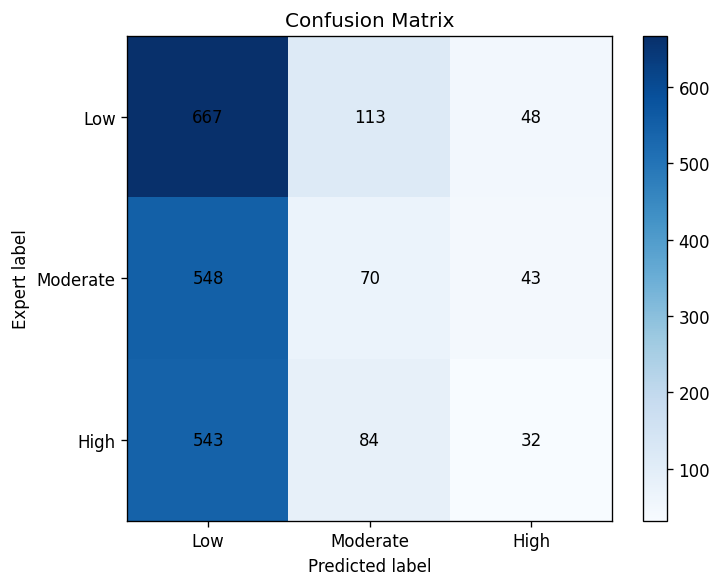

In [51]:
y_true = eval_df['expert_num'].to_numpy()
y_pred = eval_df['pred_num'].to_numpy()

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(
    cm,
    index=['Expert Low', 'Expert Medium', 'Expert High'],
    columns=['Predicted Low', 'Predicted Medium', 'Predicted High'],
)
display(cm_df)

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['Low', 'Moderate', 'High'])
ax.set_yticklabels(['Low', 'Moderate', 'High'])
ax.set_xlabel('Predicted label')
ax.set_ylabel('Expert label')
ax.set_title('Confusion Matrix')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Metric 2: Per-Class Recall

In [52]:
recalls = recall_score(y_true, y_pred, labels=[0, 1, 2], average=None, zero_division=0)
recall_df = pd.DataFrame({
    'Class': LABEL_ORDER,
    'Recall': recalls,
    'Interpretation': [
        'Ability to identify low-affinity pairs',
        'Ability to identify medium-affinity pairs',
        'Ability to identify high-affinity pairs',
    ],
})
display(recall_df)

,Class,Recall,Interpretation
0,Low,0.805556,Ability to identify low-affinity pairs
1,Moderate,0.105900,Ability to identify medium-affinity pairs
2,High,0.048558,Ability to identify high-affinity pairs


## Metric 3 and 4: Quadratic Weighted Kappa and Mean Signed Error

In [53]:
qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
mean_signed_error = float(np.mean(y_pred - y_true))

print(f'Quadratic Weighted Kappa = {qwk:.4f}')
print(f'Mean signed error        = {mean_signed_error:.4f}')

if model_prediction_cols:
    model_bias_rows = []
    for col in model_prediction_cols:
        if col not in eval_df.columns:
            continue

        pred_clean = eval_df[col].map(normalize_label)
        temp = eval_df[['expert_num']].copy()
        temp['pred_clean'] = pred_clean
        temp = temp.dropna(subset=['pred_clean'])
        if temp.empty:
            continue

        temp['pred_num_model'] = temp['pred_clean'].map(LABEL_TO_NUM).astype(int)
        mse_model = float(np.mean(temp['pred_num_model'] - temp['expert_num']))
        model_bias_rows.append({'model_prediction_col': col, 'mean_signed_error': mse_model, 'n_pairs': len(temp)})

    if model_bias_rows:
        display(pd.DataFrame(model_bias_rows).sort_values('mean_signed_error', ascending=False))
    else:
        print('No valid model-level bias rows were computed.')

Quadratic Weighted Kappa = -0.0133
Mean signed error        = -0.6825


## Metric 5: Reliability Curve

If `agreement_strength_col` is present, it is used directly.
Otherwise, if `panel_vote_cols` is provided, agreement strength is computed as the fraction of panel votes matching the final predicted label.

In [54]:
reliability_df = None

def compute_agreement_strength(row, pred_col, vote_cols):
    final_label = row[pred_col]
    votes = row[vote_cols].dropna()
    if len(votes) == 0:
        return np.nan
    votes_clean = votes.map(normalize_label)
    votes_clean = votes_clean.dropna()
    if len(votes_clean) == 0:
        return np.nan
    return float((votes_clean == final_label).sum() / len(votes_clean))

if agreement_strength_col is not None and agreement_strength_col in eval_df.columns:
    work = eval_df.copy()
    work['agreement_strength'] = pd.to_numeric(work[agreement_strength_col], errors='coerce')
elif panel_vote_cols:
    missing_votes = [c for c in panel_vote_cols if c not in eval_df.columns]
    if missing_votes:
        print(f'Skipping reliability curve: missing panel vote columns: {missing_votes}')
        work = None
    else:
        work = eval_df.copy()
        work['agreement_strength'] = work.apply(
            compute_agreement_strength, axis=1, args=('pred_label_clean', panel_vote_cols)
        )
else:
    print('Skipping reliability curve: set agreement_strength_col or panel_vote_cols to compute it.')
    work = None

if work is not None:
    rel = work.dropna(subset=['agreement_strength']).copy()
    rel = rel[(rel['agreement_strength'] >= 0.0) & (rel['agreement_strength'] <= 1.0)].copy()

    if len(rel) == 0:
        print('Skipping reliability curve: no usable agreement strength values in [0, 1].')
    else:
        rel['is_correct'] = (rel['pred_num'] == rel['expert_num']).astype(int)

        bins = [0.0, 0.5, 0.67, 0.83, 1.0]
        rel['agreement_bin'] = pd.cut(rel['agreement_strength'], bins=bins, include_lowest=True)

        reliability_df = (
            rel.groupby('agreement_bin', observed=False)
            .agg(n_cases=('is_correct', 'size'), accuracy=('is_correct', 'mean'))
            .reset_index()
        )
        reliability_df = reliability_df[reliability_df['n_cases'] > 0].copy()
        reliability_df['bin_midpoint'] = reliability_df['agreement_bin'].apply(lambda x: x.mid)

        display(reliability_df[['agreement_bin', 'n_cases', 'accuracy']])

        fig, ax = plt.subplots()
        ax.plot(reliability_df['bin_midpoint'], reliability_df['accuracy'], marker='o')
        ax.set_xlabel('Agreement strength (bin midpoint)')
        ax.set_ylabel('Accuracy vs expert')
        ax.set_title('Reliability Curve')
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

Skipping reliability curve: set agreement_strength_col or panel_vote_cols to compute it.


## Optional: Cluster Bootstrap Confidence Intervals

Bootstrap resamples complete abstracts (clusters), not individual rows.

Set `RUN_BOOTSTRAP = True` near the top to run this section.

In [55]:
bootstrap_summary = None

if RUN_BOOTSTRAP:
    if abstract_id_col_inferred is None or abstract_id_col_inferred not in eval_df.columns:
        print('Bootstrap skipped: abstract_id_col is missing.')
    else:
        rng = np.random.default_rng(BOOTSTRAP_SEED)
        abstract_ids = pd.Series(eval_df[abstract_id_col_inferred].dropna().unique())

        if len(abstract_ids) == 0:
            print('Bootstrap skipped: no abstract IDs available.')
        else:
            qwk_samples = []
            mse_samples = []
            recall_samples = []

            for _ in range(N_BOOT):
                sampled_ids = rng.choice(abstract_ids.to_numpy(), size=len(abstract_ids), replace=True)
                sampled_parts = [eval_df[eval_df[abstract_id_col_inferred] == aid] for aid in sampled_ids]
                boot_df = pd.concat(sampled_parts, ignore_index=True)

                y_t = boot_df['expert_num'].to_numpy()
                y_p = boot_df['pred_num'].to_numpy()

                qwk_samples.append(cohen_kappa_score(y_t, y_p, weights='quadratic'))
                mse_samples.append(float(np.mean(y_p - y_t)))
                recall_samples.append(recall_score(y_t, y_p, labels=[0, 1, 2], average=None, zero_division=0))

            recall_arr = np.vstack(recall_samples)

            def ci(values, alpha=0.05):
                lo = np.nanpercentile(values, 100 * (alpha / 2))
                hi = np.nanpercentile(values, 100 * (1 - alpha / 2))
                return float(lo), float(hi)

            qwk_ci = ci(np.array(qwk_samples))
            mse_ci = ci(np.array(mse_samples))
            low_ci = ci(recall_arr[:, 0])
            med_ci = ci(recall_arr[:, 1])
            high_ci = ci(recall_arr[:, 2])

            bootstrap_summary = pd.DataFrame([
                {'Metric': 'Quadratic Weighted Kappa', 'CI_2.5%': qwk_ci[0], 'CI_97.5%': qwk_ci[1]},
                {'Metric': 'Recall Low', 'CI_2.5%': low_ci[0], 'CI_97.5%': low_ci[1]},
                {'Metric': 'Recall Medium', 'CI_2.5%': med_ci[0], 'CI_97.5%': med_ci[1]},
                {'Metric': 'Recall High', 'CI_2.5%': high_ci[0], 'CI_97.5%': high_ci[1]},
                {'Metric': 'Mean Signed Error', 'CI_2.5%': mse_ci[0], 'CI_97.5%': mse_ci[1]},
            ])
            display(bootstrap_summary)
else:
    print('Bootstrap disabled (RUN_BOOTSTRAP = False).')

Bootstrap disabled (RUN_BOOTSTRAP = False).


## Final Summary Table

In [56]:
summary_rows = [
    {'Quantity': 'Evaluated pairs', 'Value': int(len(eval_df))},
    {
        'Quantity': 'Unique abstracts',
        'Value': int(eval_df[abstract_id_col_inferred].nunique())
        if abstract_id_col_inferred is not None and abstract_id_col_inferred in eval_df.columns
        else 'N/A',
    },
    {'Quantity': 'Quadratic Weighted Kappa', 'Value': float(qwk)},
    {'Quantity': 'Low recall', 'Value': float(recalls[0])},
    {'Quantity': 'Medium recall', 'Value': float(recalls[1])},
    {'Quantity': 'High recall', 'Value': float(recalls[2])},
    {'Quantity': 'Mean signed error', 'Value': float(mean_signed_error)},
]

if reliability_df is not None and len(reliability_df) > 0:
    summary_rows.extend([
        {'Quantity': 'Reliability curve available', 'Value': 'Yes'},
        {'Quantity': 'Lowest agreement-bin accuracy', 'Value': float(reliability_df['accuracy'].min())},
        {'Quantity': 'Highest agreement-bin accuracy', 'Value': float(reliability_df['accuracy'].max())},
    ])
else:
    summary_rows.append({'Quantity': 'Reliability curve available', 'Value': 'No'})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Quantity,Value
0,Evaluated pairs,2148
1,Unique abstracts,100
2,Quadratic Weighted Kappa,-0.013269
3,Low recall,0.805556
4,Medium recall,0.1059
5,High recall,0.048558
6,Mean signed error,-0.682495
7,Reliability curve available,No


## Practical Decision Rules

- Good Quadratic Weighted Kappa and balanced recall across Low, Medium, and High: the three-class pipeline is likely acceptable.
- Poor Medium recall: the Medium category may be unstable; consider a binary first-stage classifier followed by adjudication of relevant cases.
- Good Low and High recall but weak Medium recall: the panel may be behaving as a binary relevant/not-relevant classifier.
- Positive mean signed error: the pipeline tends to overestimate affinity.
- Negative mean signed error: the pipeline tends to underestimate affinity.
- Mean signed error near zero: no average directional bias, but performance may still be poor.
- Increasing reliability curve: panel agreement or confidence is informative.
- Flat reliability curve: possible correlated or monoculture error.
- High-agreement cases with low accuracy: strong evidence of shared model bias relative to the expert.